# FoldForge — Milestone 0: Geometry & Foldability Theory

This notebook is the M0 demo. It loads three classic crease patterns, draws each
one with mountain/valley colouring, and reports whether it can fold completely
flat using **Kawasaki's** and **Maekawa's** theorems.

Nothing here folds paper into 3D yet — that is Milestone 1. M0 is about
representing the *flat* pattern correctly and screening it for flat-foldability.

**The two theorems, in one breath each:**
- **Kawasaki:** around an interior vertex, the alternating sum of the wedge
  angles is zero (equivalently: odd wedges total 180°, even wedges total 180°).
- **Maekawa:** at an interior vertex, *(mountains − valleys) = ±2*.

Both are *necessary* conditions: failing either means "cannot fold flat";
passing both is a strong yes but not an absolute proof (layers can still
collide). We say so honestly.

In [1]:
import matplotlib.pyplot as plt

from foldforge.geometry import examples
from foldforge import foldability_report, render_pattern

patterns = {name: gen() for name, gen in examples.GENERATORS.items()}
list(patterns.values())

[CreasePattern('miura_4x4': 25 vertices, 40 edges, 16 faces),
 CreasePattern('single_vertex': 5 vertices, 8 edges, 0 faces),
 CreasePattern('waterbomb_base': 9 vertices, 16 edges, 0 faces)]

## 1. Render the three patterns

Mountains are red dash-dot, valleys are blue dashed, the paper border is solid
black. (The line *styles* differ too, so the figure still reads in greyscale.)

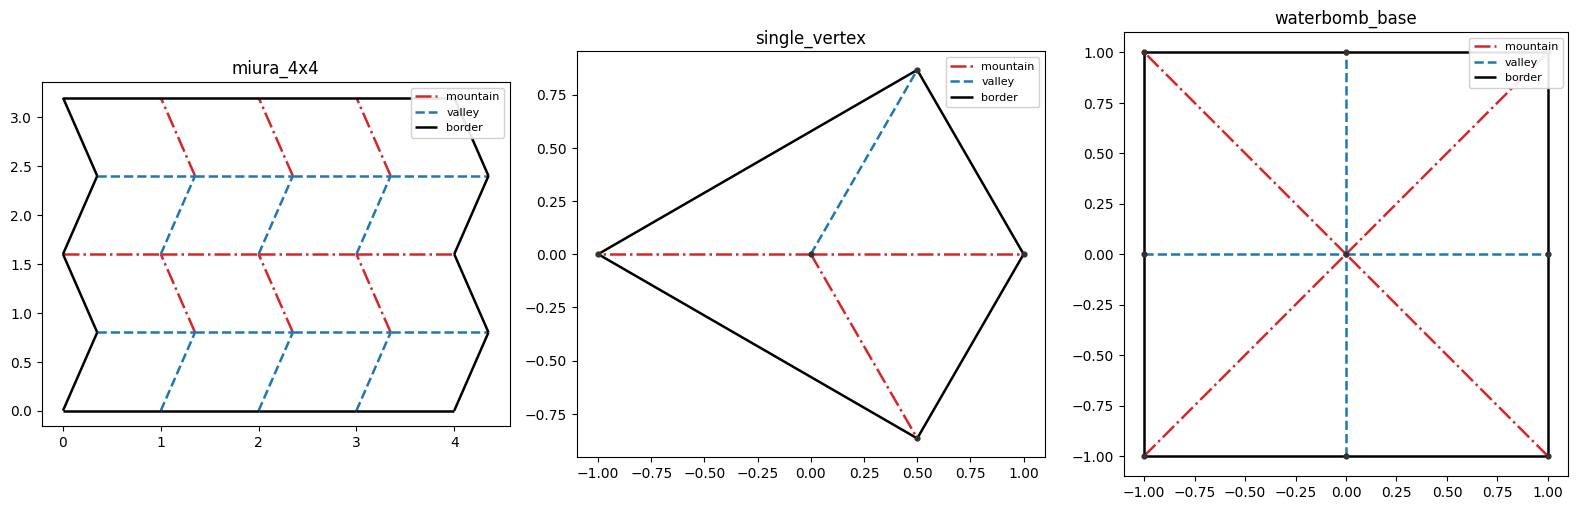

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, p) in zip(axes, patterns.items()):
    render_pattern(p, ax=ax, show_vertices=(name != "miura"))
plt.tight_layout()
plt.show()

## 2. Foldability report for each pattern

The **Miura-ori** and the **single vertex** are flat-foldable. The **waterbomb
base** is a *3D* base, not a flat fold, so it should fail — and it should fail on
**Maekawa**, not Kawasaki (its angles are all 45° and fine; it's the
mountain/valley balance that's wrong).

In [3]:
for name, p in patterns.items():
    report = foldability_report(p)
    print(f"=== {name} ===")
    print(p)
    print(report.summary())
    print()

=== miura ===
CreasePattern('miura_4x4': 25 vertices, 40 edges, 16 faces)
flat-foldable (passes both theorems)

=== single_vertex ===
CreasePattern('single_vertex': 5 vertices, 8 edges, 0 faces)
flat-foldable (passes both theorems)

=== waterbomb_base ===
CreasePattern('waterbomb_base': 9 vertices, 16 edges, 0 faces)
NOT flat-foldable: 1 of 1 interior vertices fail
  vertex 8: kawasaki=True maekawa=False



## 3. A vertex, up close

Let's look at the wedge angles and crease types around the centre of the
single-vertex pattern, so the theorems aren't a black box. The four wedges are
60°, 120°, 120°, 60° (Kawasaki: 60+120 = 120+60 = 180 ✓) and the creases are
3 mountains + 1 valley (Maekawa: |3−1| = 2 ✓).

In [4]:
p = examples.single_vertex()
print("wedge angles around centre:", [round(a, 1) for a in p.sector_angles(0)])
print("creases (angle°, type):",
      [(round(a, 1), k) for a, k, _ in p.vertex_creases(0)])

wedge angles around centre: [60.0, 120.0, 120.0, 60.0]
creases (angle°, type): [(0.0, 'M'), (60.0, 'V'), (180.0, 'M'), (300.0, 'M')]


## 4. Corrupt a Miura vertex — the validator should catch it

If we nudge a single interior vertex out of place, the wedge angles no longer
balance, and Kawasaki must report the pattern as no longer flat-foldable. This
is the M0 acceptance test, shown live.

In [5]:
import numpy as np

good = examples.miura()
print("clean Miura flat-foldable:", foldability_report(good).flat_foldable)

bad = examples.miura()
bad.vertices[bad.n_vertices // 2] += np.array([0.25, 0.18])
report = foldability_report(bad)
print("nudged Miura flat-foldable:", report.flat_foldable)
print(report.summary())

clean Miura flat-foldable: True
nudged Miura flat-foldable: False
NOT flat-foldable: 5 of 9 interior vertices fail
  vertex 7: kawasaki=False maekawa=True
  vertex 11: kawasaki=False maekawa=True
  vertex 12: kawasaki=False maekawa=True
  vertex 13: kawasaki=False maekawa=True
  vertex 17: kawasaki=False maekawa=True


## Recap

- A crease pattern is loaded/stored in the standard **FOLD** JSON format.
- We can render it and ask, per vertex, whether **Kawasaki** and **Maekawa**
  hold, and roll that up into a whole-pattern verdict.
- The validators correctly accept the Miura, reject the waterbomb base, and
  catch a corrupted Miura.

**Next (M1):** drive the fold angles from flat to folded and watch the pattern
become a 3D shape.